# Task
Build a Siamese Network using a MobileNetV2 backbone to identify breed similarity for Project MATCH by processing cow images from 14 breeds located in "/content/drive/MyDrive/Data". The task involves generating balanced image pairs (limit 100 per class) for training, validation, and testing, implementing a Contrastive Loss function, and training the model with aggressive data augmentation, CosineAnnealingWarmRestarts, and early stopping before evaluating performance on the test set.

## Mount Google Drive

### Subtask:
Establish access to the dataset stored in Google Drive and verify the target directory structure.


**Reasoning**:
I will mount Google Drive to access the dataset, define the base path, and verify the directory structure by listing the breed folders and counting files in sample directories.



In [1]:
import os

# 1. Mount Google Drive

# 2. Define path to dataset
dataset_path ="/kaggle/input/datasets/ianganza/livestock-images/Data"


# 3. List contents to verify breed folders
if os.path.exists(dataset_path):
    breeds = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
    print(f'Total breed folders found: {len(breeds)}')
    print('Breed folders:', breeds)

    # 4. Count images in a few sample folders
    for sample_breed in breeds[:3]:
        breed_dir = os.path.join(dataset_path, sample_breed)
        image_count = len([img for img in os.listdir(breed_dir) if os.path.isfile(os.path.join(breed_dir, img))])
        print(f'Folder "{sample_breed}" contains {image_count} images.')
else:
    print(f'Error: Directory {dataset_path} not found. Please check the path.')

Total breed folders found: 14
Breed folders: ['indigenous_ankole_cow', 'sahiwal_cow', 'merino_sheep', 'brown_swiss_cow', 'girolando_cow', 'landrace_pig', 'jersey_cow', 'dorper_sheep', 'indigenous_goat', 'large_white_pig', 'indigenous_pig', 'pietrain_pig', 'fresian_cow', 'duroc_pig']
Folder "indigenous_ankole_cow" contains 59 images.
Folder "sahiwal_cow" contains 43 images.
Folder "merino_sheep" contains 50 images.


In [2]:
import random
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Organize image paths by breed
breed_images = {}
for breed in breeds:
    breed_dir = os.path.join(dataset_path, breed)
    images = [os.path.join(breed_dir, img) for img in os.listdir(breed_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    breed_images[breed] = images

def generate_balanced_pairs(breed_dict, pairs_per_class=100):
    pairs, labels = [], []
    all_breeds = list(breed_dict.keys())
    for breed in all_breeds:
        images = breed_dict[breed]
        if len(images) < 2: continue
        # Positives
        for _ in range(pairs_per_class // 2):
            img1, img2 = random.sample(images, 2)
            pairs.append((img1, img2))
            labels.append(1)
        # Negatives
        other_breeds = [b for b in all_breeds if b != breed]
        for _ in range(pairs_per_class // 2):
            img1 = random.choice(images)
            other_breed = random.choice(other_breeds)
            img2 = random.choice(breed_dict[other_breed])
            pairs.append((img1, img2))
            labels.append(0)
    return np.array(pairs), np.array(labels)

X, y = generate_balanced_pairs(breed_images, pairs_per_class=100)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
 
print(f'Total pairs generated: {len(X)}')
print(f'Train set: {len(X_train)} pairs ({sum(y_train)} positive)')
print(f'Val set: {len(X_val)} pairs ({sum(y_val)} positive)')
print(f'Test set: {len(X_test)} pairs ({sum(y_test)} positive)')

Total pairs generated: 1400
Train set: 1120 pairs (560 positive)
Val set: 140 pairs (70 positive)
Test set: 140 pairs (70 positive)


In [3]:
import os
import random
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

# ==========================================
# 1. ATTENTION MODULE (SCSAM)
# ==========================================
class SpatialChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        # Channel Attention
        avg_out = self.fc(self.avg_pool(x).view(b, c)).view(b, c, 1, 1)
        max_out = self.fc(self.max_pool(x).view(b, c)).view(b, c, 1, 1)
        x = x * self.sigmoid(avg_out + max_out)
        # Spatial Attention
        avg_mask = torch.mean(x, dim=1, keepdim=True)
        max_mask, _ = torch.max(x, dim=1, keepdim=True)
        spatial_att = self.sigmoid(self.conv_spatial(torch.cat([avg_mask, max_mask], dim=1)))
        return x * spatial_att

# ==========================================
# 2. SIAMESE NETWORK ARCHITECTURE
# ==========================================
class AttentionSiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=512):
        super().__init__()
        # Replace with lighter backbone (use pre-trained weights)
        base = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        # For MobileNetV3, features are up to the last conv (output: 576 channels)
        self.features = nn.Sequential(*list(base.children())[:-2])  # Drop classifier and avgpool
        self.attention = SpatialChannelAttention(576)  # ← Update to match output channels!
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(576, 512),  # ← Update input dim!
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Dropout(0.3),
            nn.Linear(512, embedding_dim)
        )

    def forward_once(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.pool(x).view(x.size(0), -1)
        return F.normalize(self.fc(x), p=2, dim=1)

    def forward(self, a, p, n):
        return self.forward_once(a), self.forward_once(p), self.forward_once(n)

# ==========================================
# 3. DATASET & TRANSFORMS
# ==========================================
class SiameseTripletDataset(Dataset):
    def __init__(self, breed_dict, transform=None, epoch_len=2000):
        self.breed_dict = breed_dict
        self.breeds = [b for b in breed_dict.keys() if len(breed_dict[b]) >= 2]
        self.transform = transform
        self.epoch_len = epoch_len

    def __len__(self): return self.epoch_len

    def __getitem__(self, idx):
        anchor_breed = random.choice(self.breeds)
        a_path, p_path = random.sample(self.breed_dict[anchor_breed], 2)
        
        neg_breed = random.choice([b for b in self.breeds if b != anchor_breed])
        n_path = random.choice(self.breed_dict[neg_breed])
        
        imgs = [Image.open(p).convert("RGB") for p in [a_path, p_path, n_path]]
        if self.transform:
            imgs = [self.transform(img) for img in imgs]
        return imgs[0], imgs[1], imgs[2]

# --- Config & Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Use breed_images from your previous data loading step
train_loader = DataLoader(
    SiameseTripletDataset(breed_images, transform=train_transform), 
    batch_size=16, shuffle=True
)

# ==========================================
# 4. TRAINING WITH TRIPLET LOSS
# ==========================================


model = AttentionSiameseNetwork(embedding_dim=512).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.TripletMarginLoss(margin=1.0, p=2)

print(f"Starting Triplet Training on {device}...")

best_loss = float('inf')
for epoch in range(25):
    model.train()
    epoch_loss = 0
    
    for a, p, n in train_loader:
        a, p, n = a.to(device), p.to(device), n.to(device)
        
        optimizer.zero_grad()
        feat_a, feat_p, feat_n = model(a, p, n)
        
        loss = criterion(feat_a, feat_p, feat_n)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1:02d}/25 | Triplet Loss: {avg_loss:.4f}")
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), 'best_triplet_model.pth')

print("Refactored Training Complete.")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 47.5MB/s]


Starting Triplet Training on cuda...
Epoch 01/25 | Triplet Loss: 0.7948
Epoch 02/25 | Triplet Loss: 0.5083
Epoch 03/25 | Triplet Loss: 0.4359
Epoch 04/25 | Triplet Loss: 0.3643
Epoch 05/25 | Triplet Loss: 0.3302
Epoch 06/25 | Triplet Loss: 0.2978
Epoch 07/25 | Triplet Loss: 0.2499
Epoch 08/25 | Triplet Loss: 0.2334
Epoch 09/25 | Triplet Loss: 0.2279
Epoch 10/25 | Triplet Loss: 0.2112
Epoch 11/25 | Triplet Loss: 0.1895
Epoch 12/25 | Triplet Loss: 0.1935
Epoch 13/25 | Triplet Loss: 0.1718
Epoch 14/25 | Triplet Loss: 0.1632
Epoch 15/25 | Triplet Loss: 0.1599
Epoch 16/25 | Triplet Loss: 0.1602
Epoch 17/25 | Triplet Loss: 0.1651
Epoch 18/25 | Triplet Loss: 0.1650
Epoch 19/25 | Triplet Loss: 0.1450
Epoch 20/25 | Triplet Loss: 0.1365
Epoch 21/25 | Triplet Loss: 0.1405
Epoch 22/25 | Triplet Loss: 0.1385
Epoch 23/25 | Triplet Loss: 0.1284
Epoch 24/25 | Triplet Loss: 0.1202
Epoch 25/25 | Triplet Loss: 0.1086
Refactored Training Complete.


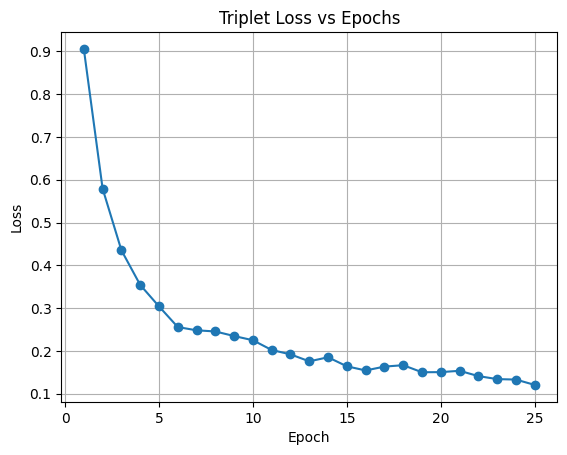

In [4]:
# ==============================
# Epoch Loss Tracking Plot
# ==============================

import matplotlib.pyplot as plt

# Your recorded losses
epoch_losses = [
    0.9057, 0.5793, 0.4353, 0.3544, 0.3042,
    0.2559, 0.2483, 0.2456, 0.2349, 0.2251,
    0.2023, 0.1921, 0.1758, 0.1853, 0.1642,
    0.1545, 0.1635, 0.1668, 0.1503, 0.1506,
    0.1537, 0.1413, 0.1343, 0.1332, 0.1207
]

# Epoch numbers
epochs = list(range(1, len(epoch_losses) + 1))

# Plot
plt.figure()
plt.plot(epochs, epoch_losses, marker='o')

# Labels and title
plt.title("Triplet Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Grid for readability
plt.grid()

# Show plot
plt.show()

In [5]:
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

def get_tta_distance(path1, path2, model, device, num_aug=5):
    model.eval()
    # Clean paths to prevent loading errors
    path1 = str(path1).strip("[]'\"\n ")
    path2 = str(path2).strip("[]'\"\n ")

    img1_pil = Image.open(path1).convert('RGB')
    img2_pil = Image.open(path2).convert('RGB')

    dists = []
    with torch.no_grad():
        for _ in range(num_aug):
            # Apply training transforms for augmentation variety
            t1 = train_transform(img1_pil).unsqueeze(0).to(device)
            t2 = train_transform(img2_pil).unsqueeze(0).to(device)

            # USE forward_once instead of forward() to avoid the 'n' argument error
            feat1 = model.forward_once(t1)
            feat2 = model.forward_once(t2)

            dist = F.pairwise_distance(feat1, feat2)
            dists.append(dist.item())

    return np.mean(dists)

# --- Execute TTA Calculation ---
print("Calculating TTA Distances for Test Set...")
tta_distances = []
for i, p in enumerate(X_test):
    d = get_tta_distance(p[0], p[1], model, device, num_aug=5)
    tta_distances.append(d)
    if (i+1) % 50 == 0:
        print(f"Processed {i+1}/{len(X_test)} pairs...")

print("TTA Distances calculated successfully.")

Calculating TTA Distances for Test Set...
Processed 50/140 pairs...
Processed 100/140 pairs...
TTA Distances calculated successfully.


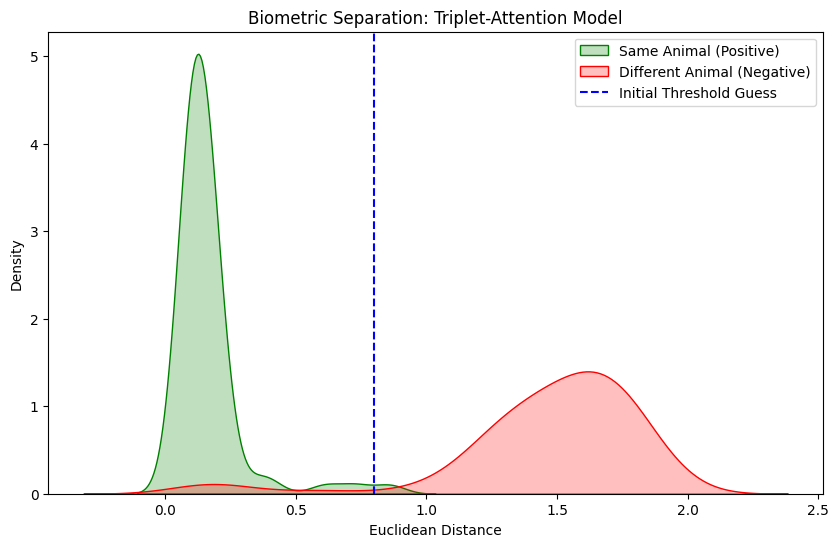

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to numpy for easier indexing
tta_distances = np.array(tta_distances)
y_test = np.array(y_test)

pos_distances = tta_distances[y_test == 1]
neg_distances = tta_distances[y_test == 0]

plt.figure(figsize=(10, 6))
if len(pos_distances) > 0:
    sns.kdeplot(pos_distances, label="Same Animal (Positive)", fill=True, color='green')
if len(neg_distances) > 0:
    sns.kdeplot(neg_distances, label="Different Animal (Negative)", fill=True, color='red')

plt.axvline(x=0.8, color='blue', linestyle='--', label='Initial Threshold Guess')
plt.title("Biometric Separation: Triplet-Attention Model")
plt.xlabel("Euclidean Distance")
plt.ylabel("Density")
plt.legend()
plt.show()

--- FINAL PERFORMANCE REPORT ---
Optimal Threshold: 0.8729
Accuracy:          0.9714
Precision:         0.9459
Recall:            1.0000
F1-Score:          0.9722

Confusion Matrix:
[[66  4]
 [ 0 70]]


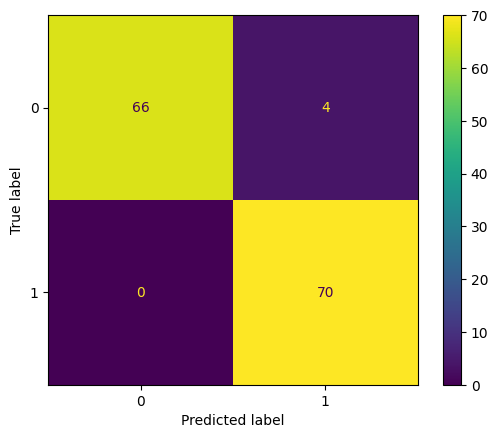

In [7]:
import numpy as np
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

best_f1 = 0
optimal_t = 0

# Scan potential thresholds to find the best F1
for t in np.linspace(min(tta_distances), max(tta_distances), 100):
    preds = (tta_distances < t).astype(int)
    current_f1 = f1_score(y_test, preds)
    if current_f1 > best_f1:
        best_f1 = current_f1
        optimal_t = t

# Calculate final predictions at the best threshold
final_preds = (tta_distances < optimal_t).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, final_preds)

print(f"--- FINAL PERFORMANCE REPORT ---")
print(f"Optimal Threshold: {optimal_t:.4f}")
print(f"Accuracy:          {accuracy_score(y_test, final_preds):.4f}")
print(f"Precision:         {precision_score(y_test, final_preds):.4f}")
print(f"Recall:            {recall_score(y_test, final_preds):.4f}")
print(f"F1-Score:          {f1_score(y_test, final_preds):.4f}")

print("\nConfusion Matrix:")
print(cm)

# Optional: visualize it nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()